In [11]:
import numpy as np
import time
import sys
import os

import numpy as np
import yfinance as fy
import QuantLib as ql
from typing import Optional, Union
import pandas as pd
import matplotlib.pyplot as plt
import multiprocess
import seaborn as sb
from tqdm import tqdm

from inception.instruments.constant_parameters import NOTES_PARAMETERS
from inception.utils import timer
from inception.quantlib_python import date_to_date
from inception.instruments import ReferenceMultiIndexReturnSimulator, MultiAssetAutoCallableNote

import mocaxextendpy.mocax_extend as me

In [12]:
parameters = NOTES_PARAMETERS['CIBC Multi Assets One']
start_date =  pd.Timestamp('2024-02-14')
days_interval = [(pd.Timestamp(d) - start_date).days for d in parameters['valuation dates']]
days_periods = list(zip([0] + [d + 1 for d in days_interval[:-1]], days_interval))
days_periods

[(0, 90),
 (91, 182),
 (183, 274),
 (275, 366),
 (367, 455),
 (456, 547),
 (548, 639),
 (640, 734),
 (735, 820),
 (821, 912),
 (913, 1006),
 (1007, 1098),
 (1099, 1185),
 (1186, 1279),
 (1280, 1370),
 (1371, 1461)]

In [13]:
def autocallable_note_pricer(x: list, additonal_data = None):
    """
    The Autocallable Notes pricer function wrapper, (adapts the original function signature to the signature expected by MoCaX)
    :param x: [stock A price, stock B price, stock C price, days after the start date]
    :param additional_data: extra parameters required by MoCaX
    """
    import numpy as np
    import pandas as pd
    from inception.instruments.constant_parameters import NOTES_PARAMETERS
    from inception.instruments import ReferenceMultiIndexReturnSimulator, MultiAssetAutoCallableNote
    
    start_date = '2024-02-14'
    # Input parameters:
    spot_price = np.array(x[:3])
    eval_date = pd.Timestamp(start_date) + pd.Timedelta(days=x[3])
    
    corr_matrix = np.array(
        [[1.        , 0.96432854, 0.80799003],
        [0.96432854, 1.        , 0.8267037 ],
        [0.80799003, 0.8267037 , 1.        ]]
    )
    issued_price = [382.82, 494.08, 142.86]
    index_vol = [0.16, 0.16, 0.16]
    risk_free_rate = 0.05
    path_num = 100_000
    d_s = 0.02
    parameters = NOTES_PARAMETERS['CIBC Multi Assets One']
    simulator = ReferenceMultiIndexReturnSimulator(issued_price, spot_price, risk_free_rate, index_vol, corr_matrix, d_s)
    notes = MultiAssetAutoCallableNote(eval_date,
                                       simulator, 
                                       parameters['valuation dates'],
                                       parameters['coupon dates'],
                                       parameters['call dates'],
                                       coupon_barrier=parameters['coupon barrier'],
                                       call_barrier=parameters['call barrier'],
                                       principal_barrier=parameters['principal barrier'],
                                       coupon_amount=parameters['coupon amount'],
                                       free_rate=risk_free_rate,
                                       n_paths=path_num)

    
    return notes.value

In [14]:
# Number of dimensions
num_dimensions = 4

# MoCaX accuracy parameters, Chebyshev Nodes
n_nodes = [20, 20, 20, 20]

# Function domain for stock A, B and C price, Time to Maturity
issued_price = [382.82, 494.08, 142.86]

lower_bound = 0.2
upper_bound = 1.5
time_bucket = 14
time_range = list(days_periods[time_bucket])
# time_range = [1371, 1430]
domain_values = [
    [issued_price[0] * lower_bound, issued_price[0] * upper_bound] ,  # Stock A price
    [issued_price[1] * lower_bound, issued_price[1] * upper_bound] ,  # Stock B price
    [issued_price[2] * lower_bound, issued_price[2] * upper_bound] ,  # Stock C price
    time_range                                  # Days after the start date
]


mocax_extend = me.MocaxExtend(num_dimensions, n_nodes, domain_values)

# -- Subgrid creation
num_scenarios = 5000
random_cheb_points = mocax_extend.subgrid_by_number(num_scenarios)

values_subgrid = []
for x in tqdm(random_cheb_points):
    values_subgrid.append(autocallable_note_pricer(x))

100%|██████████████████████████████████████████████████████████████████████████████| 4925/4925 [33:51<00:00,  2.42it/s]


In [27]:
# -- Incorporate data to rank adaptive object
mocax_extend.set_subgrid_values(values_subgrid)
mocax_extend.gen_train_val_data()

# -- Size comparison of original grid with subgrid
original_grid_size = mocax_extend.get_tensor_size()
subgrid_size = mocax_extend.get_subgrid_size()
print("Subgrid only {:.5f}% of original grid\n".format(100 * subgrid_size / original_grid_size))

""" Rank adaptive algorithm run """

# -- Parameters defined
rank_adaptive_params = {"tolerance": 1e-3,
                        "rel_tolerance": 1e-8,
                        "max_iters": 100,
                        "max_rank": 10,
                        "print_progress": True,
                        "max_rounds": 5}


# -- Training of Chebyshev Tensor in TT format
mocax_extend.run_rank_adaptive_algo(**rank_adaptive_params)


""" Serialization and deserialization """

## -- Serialization
# mocax_extend.serialize("./chebyshev_database/autocallable_tensor_extension_3.pickle")

Subgrid only 3.07812% of original grid



	At iteration: 5
	Relative error change training: 3.362e-12
	Relative error change testing: 6.117e-09
	Leaving algo

_________________________________________

Current tensor: 
Tensor train with order    = 4, 
                  row_dims = [21, 21, 21, 21], 
                  col_dims = [1, 1, 1, 1], 
                  ranks    = [1, 1, 1, 1, 1]

Trying increase rank 1 from 1 to 2


	At iteration: 5
	Relative error change training: 2.393e-13
	Relative error change testing: 2.461e-09
	Leaving algo


Current train cost: 1.274e-01
Current validation cost: 1.264e-01

Error improvement of -2.703e-02 in rank increase attempt

SUCCEEDED with completion algo. Updating to new tensor

Current max rank 2
_________________________________________

Current tensor: 
Tensor train with order    = 4, 
                  row_dims = [21, 21, 21, 21], 
                  col_dims = [1, 1, 1, 1], 
                  ranks    = [1, 2, 1, 1, 1]

Trying increase rank 2 fr



	At iteration: 69
	Relative error change training: 8.445e-14
	Relative error change testing: 8.293e-09
	Leaving algo


Current train cost: 8.175e-03
Current validation cost: 1.247e-02

Error improvement of 1.585e-03 in rank increase attempt

FAILED with completion algo. Reverting to old tensor
Current round: 7
_________________________________________

Current tensor: 
Tensor train with order    = 4, 
                  row_dims = [21, 21, 21, 21], 
                  col_dims = [1, 1, 1, 1], 
                  ranks    = [1, 4, 4, 2, 1]

Trying increase rank 1 from 4 to 5


	At iteration: 52
	Relative error change training: 1.470e-12
	Relative error change testing: 7.688e-09
	Leaving algo


Current train cost: 7.393e-03
Current validation cost: 1.161e-02

Error improvement of 7.302e-04 in rank increase attempt

FAILED with completion algo. Reverting to old tensor
Current round: 8
_________________________________________

Current tensor: 
Tensor train with order    = 4, 
             


Current train cost: 6.189e-03
Current validation cost: 2.227e-02

Error improvement of 1.147e-02 in rank increase attempt

FAILED with completion algo. Reverting to old tensor
Current round: 15
_________________________________________

Current tensor: 
Tensor train with order    = 4, 
                  row_dims = [21, 21, 21, 21], 
                  col_dims = [1, 1, 1, 1], 
                  ranks    = [1, 4, 5, 2, 1]

Trying increase rank 3 from 2 to 3

Current train cost: 6.723e-03
Current validation cost: 8.739e-02

Error improvement of 7.659e-02 in rank increase attempt

FAILED with completion algo. Reverting to old tensor
Current round: 16
_________________________________________

Current tensor: 
Tensor train with order    = 4, 
                  row_dims = [21, 21, 21, 21], 
                  col_dims = [1, 1, 1, 1], 
                  ranks    = [1, 4, 5, 2, 1]

Trying increase rank 1 from 4 to 5


	At iteration: 38
	Relative error change training: 2.906e-09
	Relative error

' Serialization and deserialization '

In [32]:
mocax_extend.serialize(f"./chebyshev_database/autocallable_tensor_extension_{time_bucket}.pickle")

## Validation

In [6]:
# -- Deserialization
# mocax_extend = me.MocaxExtend.deserialize("./chebyshev_database/autocallable_tensor_extension_14.pickle")

In [30]:
func = lambda x: np.random.uniform(x * lower_bound, x * upper_bound)
value_m = []
value_p = []
time_bucket = 14
issued_price = [382.82, 494.08, 142.86]
for _ in range(100):
    x = [func(d) for d in issued_price] + [np.random.choice(np.arange(*time_range))]
    value_m.append(mocax_extend.cheb_tensor_evals(np.array([x]))[0])
    value_p.append(autocallable_note_pricer(x))

Maximum error: 6.73116
Mean error: 1.00750


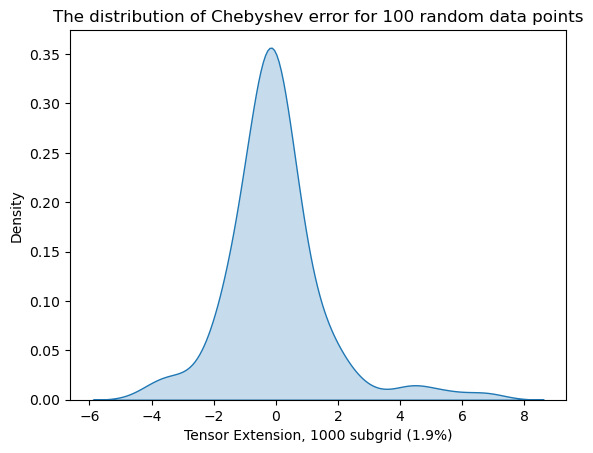

In [31]:
error_2 = (np.array(value_p) - np.array(value_m)) / np.array(value_p) * 100
sb.kdeplot(error_2,fill=True)
plt.title('The distribution of Chebyshev error for 100 random data points')
plt.xlabel('Tensor Extension, 1000 subgrid (1.9%)')

# -- Empirical error
error_sup = max(abs(error_2))
error_mean = abs(error_2).mean()

print(f"Maximum error: {error_sup:.5f}")
print(f"Mean error: {error_mean:.5f}")

In [20]:
error_2.sort()

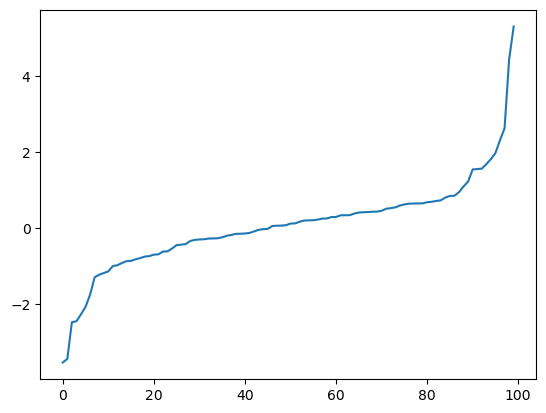

In [21]:
plt.plot(error_2)

Maximum error: 158.25985
Mean error: 7.96408


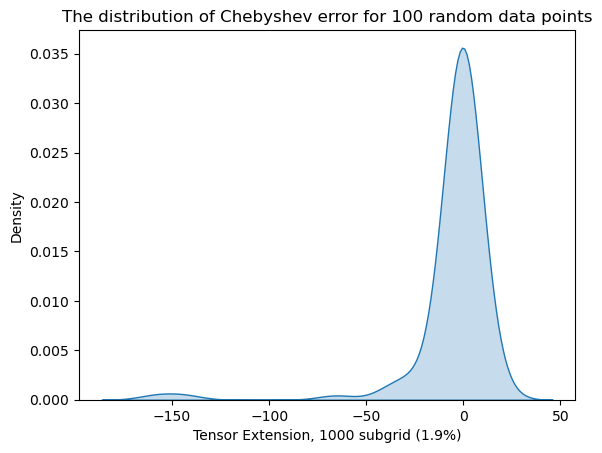

In [24]:
error_2 = (np.array(value_p) - np.array(value_m)) / np.array(value_p) * 100
sb.kdeplot(error_2,fill=True)
plt.title('The distribution of Chebyshev error for 100 random data points')
plt.xlabel('Tensor Extension, 1000 subgrid (1.9%)')

# -- Empirical error
error_sup = max(abs(error_2))
error_mean = abs(error_2).mean()

print(f"Maximum error: {error_sup:.5f}")
print(f"Mean error: {error_mean:.5f}")